In [21]:
import pandas as pd
import numpy as np
import os
import scipy.stats as stats
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import sys
import scipy.stats as stats
import arviz as az
import pyperclip

sys.path.append(os.path.abspath('..'))
import utils
import mdp_utils
import process_data as dp
import bayesian_analysis as ba

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [2]:
state_features = ['TIR', 'TIME_Q', 'MOT']
feature_names = ['Tiredness', 'Time available', 'Motivation']

action_col = "joint_cluster"

cluster_col = 'cluster_all'
cluster_vars = ['likedness', 'usefulness', 'difficulty']
cluster_cols = [col + '_cluster' for col in cluster_vars]

reward_cols = ["r_likedness", "r_usefulness", "r_diversity", "r_expert", "r_return"]
obj_names = ["Perceived Enjoyment", "Perceived Usefulness", "Diversity", "Difficulty-weighted Adherence", "Return Willingness"]

evaluation_cols = ["time_spent", "likedness", "usefulness", "PAY_next", "expert_score", "diversity"]
evaluation_names = ["Time Spent", "Likedness", "Perceived Usefulness", "Return Willingness", "Expert Usefulness", "Diversity"]

NUM_CATEGORIES = 4
NUM_FEATURES = len(state_features)
NUM_VALS_PER_FEATURE = [2, 2, 3]
NUM_USER_STATES = np.prod(NUM_VALS_PER_FEATURE)
NUM_CLUSTERS = 3
MAX_COUNT = 0
NUM_COUNT_STATES = (MAX_COUNT+1)**NUM_CATEGORIES
NUM_STATES = NUM_USER_STATES * NUM_COUNT_STATES 
NUM_ACTIONS = NUM_CLUSTERS * 2  # Within each cluster we either recommend a 'least favorite' coping category or a familiar one
NUM_OBJECTIVES = len(reward_cols)

In [4]:
data_folder = 'C:\\Users\\shirl\\Documents\\Studie\\2025-2026\\Thesis\\personalized-coping-challenges\\data\\'
results_folder = 'C:\\Users\\shirl\\Documents\\Studie\\2025-2026\\Thesis\\personalized-coping-challenges\\results\\'

# Load data
action_data = pd.read_csv(os.path.join(data_folder, 'challenge_info.csv'))
samples = pd.read_csv(os.path.join(data_folder, 'processed_samples_adjusted_full_optimistic.csv'))

actions_clustered, _, _ = dp.cluster_actions(action_data, cluster_vars, num_clusters=NUM_CLUSTERS)
# actions_clustered['cat_diff_cluster'] = actions_clustered.groupby(['category', 'expert_score']).ngroup()

df, agency_df, initial_distribution, mapping = dp.process_samples(samples, actions_clustered, state_features, NUM_VALS_PER_FEATURE, action_col, cluster_col, MAX_COUNT, NUM_CLUSTERS)
df.head(50)

Number of samples after processing: 3471
Number of agency samples: 2008


,user_id,day_number,TIR,MOT,GOOD,TIME_Q,PAY,TIR_next,MOT_next,GOOD_next,...,s_count,r_diversity,c_idx,s_idx,sp_idx,r_likedness,r_usefulness,r_return,r_expert,joint_cluster
0,1002441714,1,1,4,5,4,4,4.0,4.0,5.0,...,"[0, 0, 0, 0]",1,0,1,4,0.000000,0.000000,0.571429,0.00,5
1,1002441714,2,4,4,5,5,4,4.0,4.0,5.0,...,"[0, 0, 0, 0]",1,0,4,1,0.727273,0.285714,0.571429,0.66,4
2,1002441714,3,4,4,5,4,4,4.0,4.0,5.0,...,"[0, 0, 0, 0]",1,0,1,4,0.181818,0.142857,0.571429,1.00,5
3,1002441714,4,4,4,5,5,4,2.0,4.0,4.0,...,"[0, 0, 0, 0]",0,0,4,1,0.636364,0.571429,0.571429,0.66,1
4,1002441714,5,2,4,4,4,4,6.0,4.0,4.0,...,"[0, 0, 0, 0]",1,0,1,7,0.727273,0.571429,0.571429,1.00,5
5,1002441714,6,6,4,4,4,4,3.0,3.0,4.0,...,"[0, 0, 0, 0]",0,0,7,0,0.000000,0.000000,0.571429,0.00,0
6,1002441714,7,3,3,4,4,4,4.0,3.0,4.0,...,"[0, 0, 0, 0]",1,0,0,0,0.000000,0.000000,0.571429,0.00,5
7,1002441714,8,4,3,4,2,4,3.0,3.0,3.0,...,"[0, 0, 0, 0]",0,0,0,0,0.000000,0.000000,0.428571,0.00,0
8,1002441714,9,3,3,3,3,3,3.0,2.0,3.0,...,"[0, 0, 0, 0]",1,0,0,0,0.000000,0.000000,0.428571,0.00,4
9,1002441714,10,3,2,3,3,3,4.0,2.0,2.0,...,"[0, 0, 0, 0]",1,0,0,0,0.363636,0.142857,0.285714,0.33,4


In [5]:
stochastic_outcomes = {"likedness": 11, "usefulness": 7, "difficulty": 11, "PAY_next": 7}

for outcome, num_values in stochastic_outcomes.items():
    print(outcome + ": " + str(df[outcome].mean()) + " +- " + str(df[outcome].std()))

likedness: 4.559222433859336 +- 3.7560651990847274
usefulness: 2.6351796266514684 +- 2.257638766054035
difficulty: 2.69232726745457 +- 2.772344070776208
PAY_next: 3.993373667530971 +- 1.5780233864461435


In [6]:
def evaluate_dynamics(test_df, P_comp, P_comp_action_prior, R, P, P_global_prior, P_action_only, P_state_only, R_action_only, R_global, P_comp_action_only, P_comp_challenge_only, p_comp_overall, R_outcomes, R_outcomes_action_only, R_probs_diff_global):
    data_list = []
    for t in range(len(test_df)):
        user_row = {"t": t}
        # True values
        s_t = test_df.iloc[t]['s_idx']
        c_t = test_df.iloc[t]['c_idx']
        a_t = test_df.iloc[t][action_col]
        challenge_id = test_df.iloc[t]['challenge_id']
        s_t_next = test_df.iloc[t]['sp_idx']
        r_t = test_df.iloc[t][reward_cols].values
        completed = test_df.iloc[t]['completed']

        # Reward predictions
        r_pred = R[s_t, c_t, a_t]
        r_pred_action_only = R_action_only[a_t]
        r_pred_global = R_global
        
        for i, obj in enumerate(reward_cols):
            user_row[f'{obj}_l1_error'] = np.abs(r_t[i] - r_pred[i])
            user_row[f'{obj}_l1_error_action_only'] = np.abs(r_t[i] - r_pred_action_only[i])
            user_row[f'{obj}_l1_error_global'] = np.abs(r_t[i] - r_pred_global[i])
        # Next state likelihood
        P_s_t_next = P[s_t, a_t, s_t_next]
        user_row['next_state_likelihood'] = P_s_t_next
        user_row['next_state_likelihood_global_prior'] = P_global_prior[s_t, a_t, s_t_next]
        user_row['next_state_likelihood_action_only'] = P_action_only[a_t, s_t_next]
        user_row['next_state_likelihood_state_only'] = P_state_only[s_t, s_t_next]
        user_row['equal_state'] = (s_t_next == s_t)
        user_row['s_idx'] = s_t
        user_row['s_idx_next'] = s_t_next

        # Completion likelihood
        P_comp_pred = P_comp[s_t, a_t]
        P_comp_pred_action_only = P_comp_action_only[a_t]
        P_comp_pred_challenge_only = P_comp_challenge_only[challenge_id]
        user_row['completion_likelihood'] = P_comp_pred if completed else (1 - P_comp_pred)
        user_row['completion_likelihood_action_prior'] = P_comp_action_prior[s_t, a_t] if completed else (1 - P_comp_action_prior[s_t, a_t])
        user_row['completion_likelihood_action_only'] = P_comp_pred_action_only if completed else (1 - P_comp_pred_action_only)
        user_row['completion_likelihood_challenge_only'] = P_comp_pred_challenge_only if completed else (1 - P_comp_pred_challenge_only)
        user_row['completion_likelihood_overall'] = p_comp_overall if completed else (1 - p_comp_overall)
        user_row['completed'] = completed

        if completed:
            for outcome in stochastic_outcomes:
                outcome_value_t = test_df.iloc[t][outcome]
                # if outcome == "PAY_next" or outcome == "usefulness":
                                        
                outcome_value_t = outcome_value_t - 1  # convert 1-7 to 0-6 for indexing, for other outcomes the values are already 0-indexed
                if pd.isna(outcome_value_t):
                    continue  # Skip if outcome value is missing
                R_outcome = R_outcomes[outcome]
                user_row[f'{outcome}_likelihood'] = R_outcome[s_t, a_t, int(outcome_value_t)]

                R_outcome_action_only = R_outcomes_action_only[outcome]
                outcome_likelihood_action_only = R_outcome_action_only[a_t, int(outcome_value_t)]
                user_row[f'{outcome}_likelihood_action_only'] = outcome_likelihood_action_only

                R_outcome_global = R_probs_diff_global[outcome]
                user_row[f'{outcome}_likelihood_global'] = R_outcome_global[int(outcome_value_t)]
        data_list.append(user_row)
        
    return pd.DataFrame(data_list)

In [7]:
all_users = df['user_id'].unique()
print("Number of users:", len(all_users))

lam = 1

all_user_results = []
for test_user in all_users:

    train_df = df[df['user_id'] != test_user]
    test_df = df[df['user_id'] == test_user]
    filtered_train_df = train_df[~(train_df['completed'] == 1 & (train_df['difficulty'] == 0))]
    
    P_comp = mdp_utils.compute_completion_probabilities(train_df, NUM_USER_STATES, NUM_ACTIONS, action_col, prior='none')
    P_comp_action_prior = mdp_utils.compute_completion_probabilities(train_df, NUM_USER_STATES, NUM_ACTIONS, action_col, prior='action_only')
    R = mdp_utils.compute_rewards(filtered_train_df, NUM_USER_STATES, NUM_COUNT_STATES, NUM_ACTIONS, NUM_OBJECTIVES, reward_cols, action_col, mapping)
    R_action_only = mdp_utils.compute_avg_rewards(filtered_train_df, NUM_ACTIONS, action_col, reward_cols)
    R_global = mdp_utils.compute_rewards_global(filtered_train_df, reward_cols)
    
    P = mdp_utils.compute_transition_probabilities(train_df, NUM_USER_STATES, NUM_ACTIONS, action_col, prior='uniform', alpha=1/NUM_USER_STATES)
    P_global_prior = mdp_utils.compute_transition_probabilities(train_df, NUM_USER_STATES, NUM_ACTIONS, action_col)
    P_action_only = mdp_utils.compute_transition_probabilities_action_only(train_df, NUM_ACTIONS, action_col, NUM_USER_STATES, alpha=0)
    P_state_only = mdp_utils.compute_transition_probabilities_action_only(train_df, NUM_USER_STATES, 's_idx', NUM_USER_STATES, alpha=0)
    P_return = mdp_utils.compute_return_probabilities(train_df)
    
    P_comp_action_only = mdp_utils.compute_completion_probabilities_action_only(train_df, NUM_ACTIONS, action_col)
    P_comp_challenge_only = train_df.groupby('challenge_id')['completed'].mean().to_dict()
    p_comp_overall = train_df['completed'].mean()

    R_outcomes = {o: mdp_utils.compute_reward_probabilities(filtered_train_df, o, NUM_USER_STATES, NUM_ACTIONS, action_col, lam=lam) for o in stochastic_outcomes}

    R_outcomes_action_only = {o: mdp_utils.compute_reward_probabilities_action_only(filtered_train_df, o, NUM_ACTIONS, action_col, lam=0) for o in stochastic_outcomes}
        
    R_probs_diff_global = {o: mdp_utils.compute_reward_probabilities_global(filtered_train_df, o) for o in stochastic_outcomes}
    
    result_df = evaluate_dynamics(test_df, P_comp, P_comp_action_prior, R, P, P_global_prior, P_action_only, P_state_only, R_action_only, R_global, P_comp_action_only, P_comp_challenge_only, p_comp_overall, 
                                  R_outcomes, R_outcomes_action_only, R_probs_diff_global)
    result_df['user_id'] = test_user
    all_user_results.append(result_df)
    
combined_results = pd.concat(all_user_results, ignore_index=True)

Number of users: 314


### Reward function evaluation
To evaluate our learned reward function, we compare it against using only the action to predict the reward.

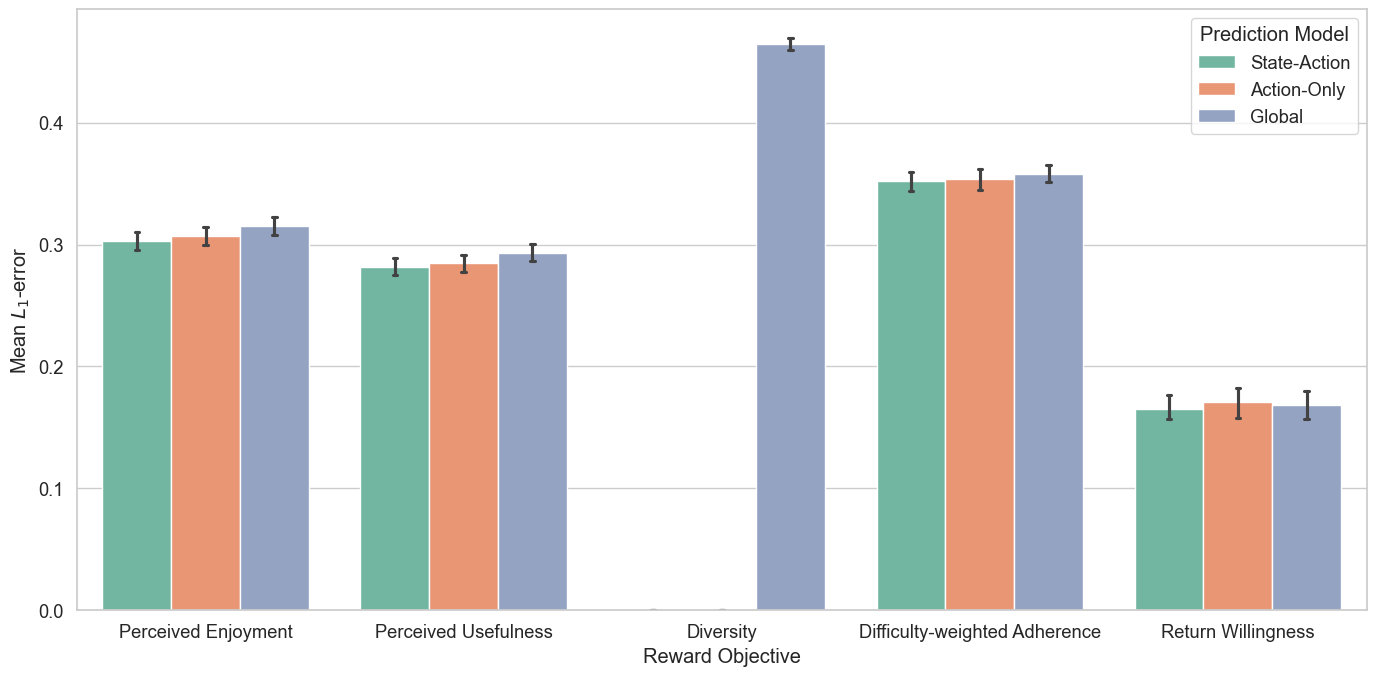

In [55]:
plot_records = []
for obj, obj_name in zip(reward_cols, obj_names):
    # if obj == "r_diversity":
    #     continue
    state_action = combined_results.groupby('user_id')[f'{obj}_l1_error'].mean()
    for err in state_action:
        plot_records.append({'Objective': obj_name, 'L1 Error': err, 'Model': 'State-Action'})
    
    action_only = combined_results.groupby('user_id')[f'{obj}_l1_error_action_only'].mean()
    for err in action_only:
        plot_records.append({'Objective': obj_name, 'L1 Error': err, 'Model': 'Action-Only'})

    global_errors = combined_results.groupby('user_id')[f'{obj}_l1_error_global'].mean()
    for err in global_errors:
        plot_records.append({'Objective': obj_name, 'L1 Error': err, 'Model': 'Global'})

viz_df = pd.DataFrame(plot_records)

plt.figure(figsize=(14, 7))
sns.set_style("whitegrid")
sns.set_context("notebook", font_scale=1.2)
ax = sns.barplot(
    data=viz_df, 
    x='Objective', 
    y='L1 Error', 
    hue='Model', 
    palette="Set2",
    capsize=.05,
    errorbar=('ci', 95)
)

plt.ylabel('Mean $L_1$-error')
plt.xlabel('Reward Objective')
plt.legend(title='Prediction Model', frameon=True)

plt.savefig(results_folder + "figures/reward_model_comparison.svg", bbox_inches='tight')
plt.tight_layout()
plt.show()

In [ ]:
results = []
for obj, obj_name in zip(reward_cols, obj_names):
    if obj == "r_diversity":
        continue  # Skip diversity for this analysis, since it is deterministic
    combined_results[f'{obj}_improvement'] = combined_results[f'{obj}_l1_error_action_only'] - combined_results[f'{obj}_l1_error']
    user_diffs = combined_results.groupby('user_id')[f'{obj}_improvement'].mean().values
    print(f"Testing {obj_name}")
    result = ba.paired_t_test(user_diffs, name=obj_name)
    results.append(result)

results_df = pd.concat(results, ignore_index=True)
pyperclip.copy(ba.to_latex_body(results_df))
results_df


Perceived Enjoyment:

Perceived Usefulness:

Difficulty-weighted Adherence:

Return Willingness:


In [56]:
results_global = []
for obj, obj_name in zip(reward_cols, obj_names):
    if obj == "r_diversity":
        continue  # Skip diversity for this analysis, since it is deterministic
    combined_results[f'{obj}_improvement_over_global'] = combined_results[f'{obj}_l1_error_global'] - combined_results[f'{obj}_l1_error']
    user_diffs = combined_results.groupby('user_id')[f'{obj}_improvement_over_global'].mean().values
    print(f"Testing {obj_name}")
    result = ba.paired_t_test(user_diffs, name=obj_name)
    results_global.append(result)

results_global_df = pd.concat(results_global, ignore_index=True)
pyperclip.copy(ba.to_latex_body(results_global_df))
results_global_df

Testing Perceived Enjoyment
Posterior probability improvement > 0: 1.0000
Testing Perceived Usefulness
Posterior probability improvement > 0: 1.0000
Testing Difficulty-weighted Adherence
Posterior probability improvement > 0: 1.0000
Testing Return Willingness
Posterior probability improvement > 0: 0.8405


,objective,mean,hdi_low,hdi_high,post_prob,small,medium,large,mean_hdi,interpretation
0,Perceived Enjoyment,0.013321,0.009698,0.016994,1.0000,1.00000,1.00000,0.97975,"\makecell{$0.013$\\$[0.010,\,0.017]$}",Virtually certain
1,Perceived Usefulness,0.011761,0.008511,0.015026,1.0000,1.00000,1.00000,0.96625,"\makecell{$0.012$\\$[0.009,\,0.015]$}",Virtually certain
2,Difficulty-weighted Adherence,0.006770,0.003793,0.009873,1.0000,0.99625,0.85650,0.29350,"\makecell{$0.007$\\$[0.004,\,0.010]$}",Virtually certain
3,Return Willingness,0.002869,-0.002600,0.008462,0.8405,0.22025,0.00525,0.00000,"\makecell{$0.003$\\$[-0.003,\,0.008]$}",Only a casual bet


In [10]:
# # prior sensitivity analysis 
# mu_priors = [(0, 1), (1, 10), (-1, 10)]
# sigma_priors = [(0, 5), (0, 10), (0, 20)]
# for obj, obj_name in zip(reward_cols, obj_names):
#     if obj == "r_diversity":
#         continue  # Skip diversity for this analysis, since it is deterministic
#     combined_results[f'{obj}_improvement'] = combined_results[f'{obj}_l1_error_action_only'] - combined_results[f'{obj}_l1_error']
#     user_diffs = combined_results.groupby('user_id')[f'{obj}_improvement'].mean().values
#     user_errs = combined_results.groupby('user_id')[f'{obj}_l1_error'].mean().values
#     user_errs_action_only = combined_results.groupby('user_id')[f'{obj}_l1_error_action_only'].mean().values
#     print(f"\n{obj_name}:")
#     for mu_prior in mu_priors:
#         for sigma_prior in sigma_priors:
#             print(f"  Mu Prior: {type(mu_prior).__name__}, Sigma Prior: {type(sigma_prior).__name__}")
#             ba.paired_t_test(user_diffs, mu_prior=mu_prior, sigma_prior=sigma_prior)

### Stochastic outcomes

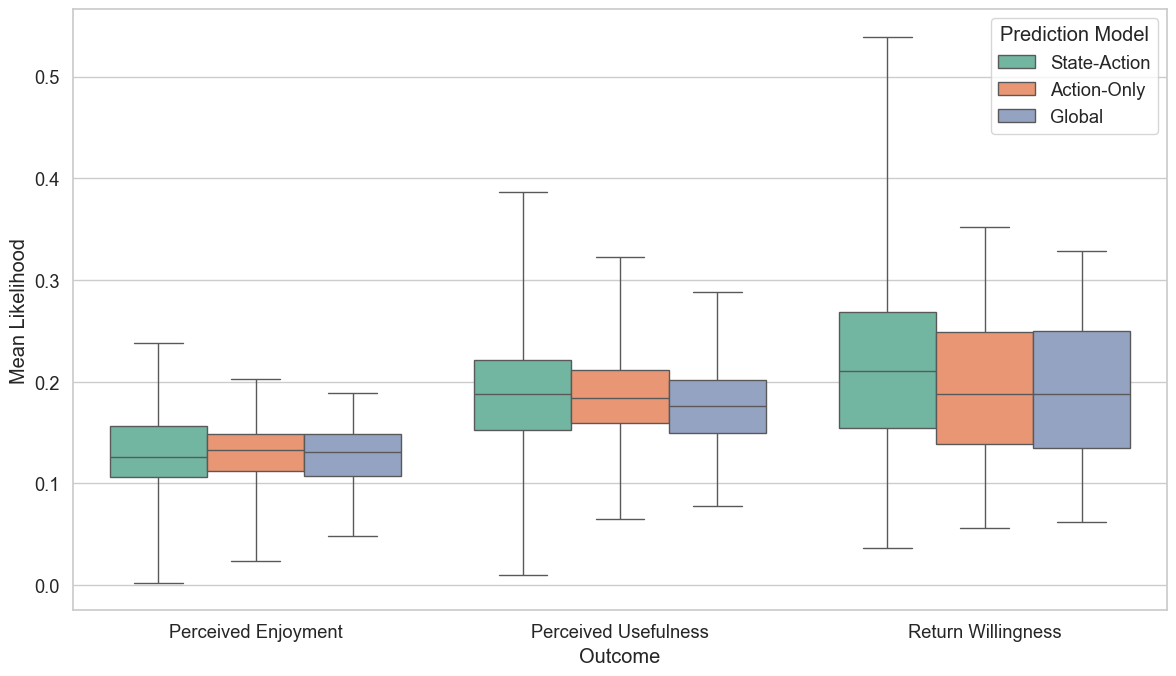

In [54]:
# plot mean likelihoods of outcomes
outcomes_to_test = {"likedness": "Perceived Enjoyment", "usefulness": "Perceived Usefulness", "PAY_next": "Return Willingness"}

plot_records = []
combined_results_completed = combined_results[combined_results['completed'] == 1]
for obj, obj_name in outcomes_to_test.items():
    state_action = combined_results_completed.groupby('user_id')[f'{obj}_likelihood'].mean()
    for prob in state_action:
        plot_records.append({'Outcome': obj_name, 'Likelihood': prob, 'Model': 'State-Action'})
    
    action_only = combined_results_completed.groupby('user_id')[f'{obj}_likelihood_action_only'].mean()
    for prob in action_only:
        plot_records.append({'Outcome': obj_name, 'Likelihood': prob, 'Model': 'Action-Only'})

    global_likelihoods = combined_results_completed.groupby('user_id')[f'{obj}_likelihood_global'].mean()
    for prob in global_likelihoods:
        plot_records.append({'Outcome': obj_name, 'Likelihood': prob, 'Model': 'Global'})

viz_df = pd.DataFrame(plot_records)

# 2. Create the plot
plt.figure(figsize=(12, 7))
sns.set_style("whitegrid")
sns.set_context("notebook", font_scale=1.2)

# Use a barplot with 95% confidence intervals (black lines)
ax = sns.boxplot(
    data=viz_df, 
    x='Outcome', 
    y='Likelihood', 
    hue='Model', 
    palette='Set2',
    whis=[0, 100]
    # capsize=.05,
    # errorbar=('ci', 95)
)

# plt.title('Predictive Performance: State-Action vs. Action-Only Reward Models', fontsize=14)
plt.ylabel('Mean Likelihood')
plt.xlabel('Outcome')
plt.legend(title='Prediction Model', frameon=True)

plt.savefig(results_folder + "figures/outcome_model_comparison.svg", bbox_inches='tight')
plt.tight_layout()
plt.show()

In [ ]:
results = []
for outcome, outcome_name in outcomes_to_test.items():
    combined_results_completed[f'{outcome}_improvement'] = combined_results_completed[f'{outcome}_likelihood'] - combined_results_completed[f'{outcome}_likelihood_action_only']
    user_diffs = combined_results_completed.groupby('user_id')[f'{outcome}_improvement'].mean().values
    print(f"Testing {outcome_name}")
    result = ba.paired_t_test(user_diffs, name=outcome_name)
    results.append(result)

results_df = pd.concat(results, ignore_index=True)
pyperclip.copy(ba.to_latex_body(results_df))
results_df

Testing Perceived Enjoyment
Posterior probability improvement > 0: 0.3780
Testing Perceived Usefulness
Posterior probability improvement > 0: 0.9818
Testing Return Willingness
Posterior probability improvement > 0: 1.0000


,objective,mean,hdi_low,hdi_high,post_prob,small,medium,large,mean_hdi,interpretation
0,Perceived Enjoyment,-0.000354,-0.002497,0.001994,0.37800,0.09925,0.00025,0.00000,"\makecell{$-0.000$\\$[-0.002,\,0.002]$}",Not worth betting against
1,Perceived Usefulness,0.003109,0.000301,0.006017,0.98175,0.67625,0.12050,0.00275,"\makecell{$0.003$\\$[0.000,\,0.006]$}",\makecell{Good bet\\too good to disregard}
2,Return Willingness,0.023905,0.019520,0.027984,1.00000,1.00000,1.00000,1.00000,"\makecell{$0.024$\\$[0.020,\,0.028]$}",Virtually certain


### User state transition dynamics evaluation

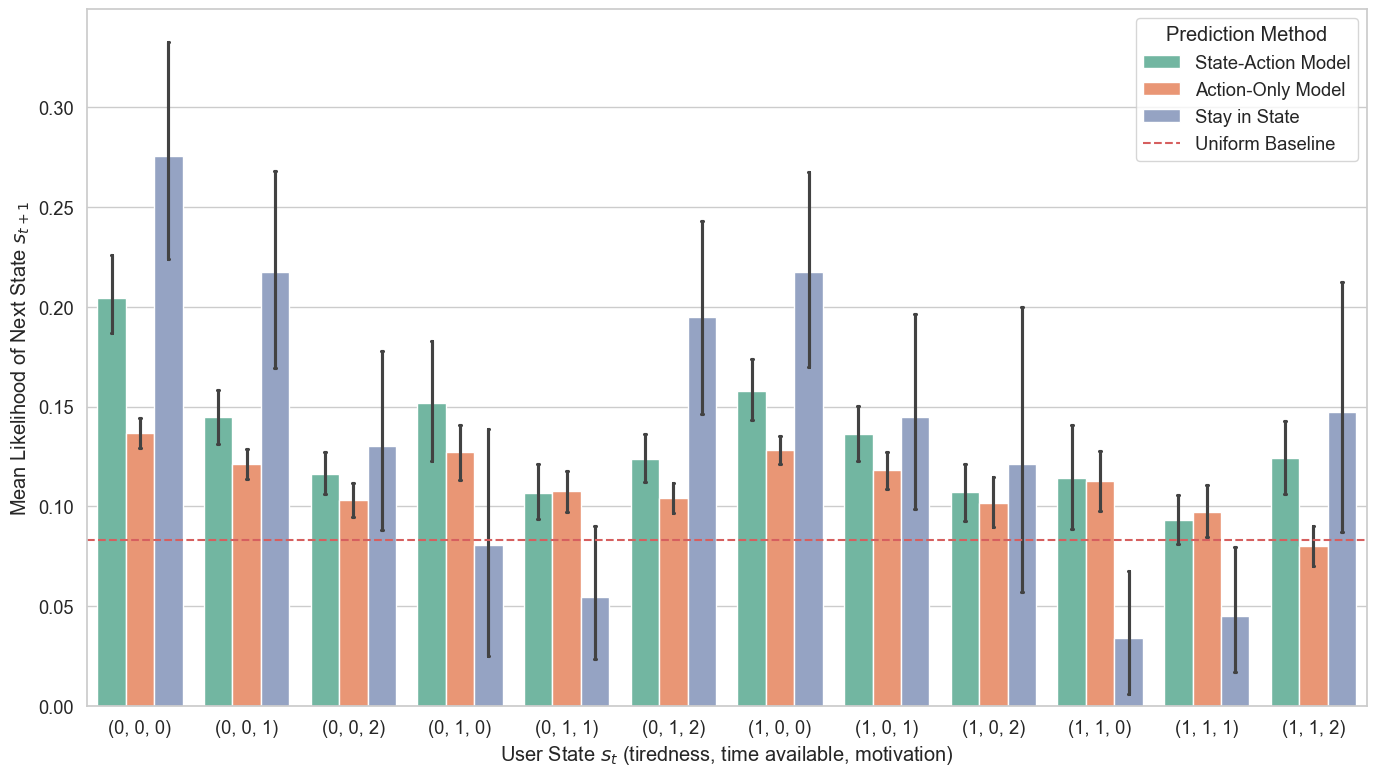

In [52]:
uniform_prob = 1.0 / NUM_USER_STATES

plot_records = []
model_map = {
    # "next_state_likelihood": "Transition Model",
    "next_state_likelihood_global_prior": "State-Action Model",
    "next_state_likelihood_action_only": "Action-Only Model",
    "equal_state": "Stay in State",
    # "next_state_likelihood_state_only": "State-Only Model"
}

plot_data = (
    combined_results_completed
    .groupby(["s_idx", "user_id"])[list(model_map.keys())]
    .mean()
    .reset_index()
    .melt(id_vars=["s_idx", "user_id"], var_name="Model", value_name="Likelihood")
)

plot_data["State"] = plot_data["s_idx"].apply(lambda x: str(utils.idx_to_user_state(x, NUM_VALS_PER_FEATURE)))
plot_data["Model"] = plot_data["Model"].map(model_map)

plt.figure(figsize=(14, 8))
sns.set_style("whitegrid")
sns.set_context("notebook", font_scale=1.2)

ax = sns.barplot(
    data=plot_data, 
    x='State', 
    y='Likelihood', 
    hue='Model', 
    palette='Set2',
    capsize=.05,
    errorbar=('ci', 95)
)

# plt.title('Next State Likelihood by User State', fontsize=16, pad=20)
plt.ylabel('Mean Likelihood of Next State $s_{t+1}$')
plt.xlabel('User State $s_t$ (tiredness, time available, motivation)')

plt.axhline(uniform_prob, color=sns.color_palette("muted")[3], linestyle='--', alpha=1, label='Uniform Baseline')
# plt.xticks(rotation=45, ha='right')

plt.legend(title='Prediction Method')
plt.savefig(results_folder + "figures/transition_model_comparison.svg", bbox_inches='tight')
plt.tight_layout()
plt.show()

In [14]:
combined_results['next_state_improvement'] = combined_results['next_state_likelihood_global_prior'] - combined_results['equal_state']

for state_idx in range(NUM_USER_STATES):
    state_diffs = combined_results[combined_results['s_idx'] == state_idx].groupby('user_id')['next_state_improvement'].mean().values
    print(f"\nState {state_idx} {utils.idx_to_user_state(state_idx, NUM_VALS_PER_FEATURE)}:")
    ba.paired_t_test(state_diffs)


State 0 (0, 0, 0):
              mean     sd  hdi_2.5%  hdi_97.5%  mcse_mean  mcse_sd  ess_bulk  \
improvement -0.069  0.016    -0.100     -0.039      0.000    0.000  3802.813   
effect_size -0.314  0.073    -0.452     -0.167      0.001    0.001  3910.883   

             ess_tail  r_hat  
improvement  2919.272    1.0  
effect_size  2969.535    1.0  
P(improvement > 0): 0.000
P(Effect Size > 0.1): 0.998
P(Effect Size > 0.2): 0.942
P(Effect Size > 0.3): 0.569

State 1 (0, 0, 1):


The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


              mean     sd  hdi_2.5%  hdi_97.5%  mcse_mean  mcse_sd  ess_bulk  \
improvement -0.000  0.039    -0.054      0.075      0.002    0.001   300.497   
effect_size  0.072  0.313    -0.317      0.744      0.020    0.012   297.292   

             ess_tail  r_hat  
improvement   917.286  1.005  
effect_size   648.457  1.006  
P(improvement > 0): 0.403
P(Effect Size > 0.1): 0.700
P(Effect Size > 0.2): 0.359
P(Effect Size > 0.3): 0.228

State 2 (0, 0, 2):
              mean     sd  hdi_2.5%  hdi_97.5%  mcse_mean  mcse_sd  ess_bulk  \
improvement  0.092  0.008     0.075      0.108      0.000    0.000  2497.608   
effect_size  1.284  0.229     0.796      1.705      0.005    0.004  1954.016   

             ess_tail  r_hat  
improvement  2362.330  1.000  
effect_size  1809.523  1.001  
P(improvement > 0): 1.000
P(Effect Size > 0.1): 1.000
P(Effect Size > 0.2): 1.000
P(Effect Size > 0.3): 1.000

State 3 (0, 1, 0):
              mean     sd  hdi_2.5%  hdi_97.5%  mcse_mean  mcse_sd  ess_

### Completion probabilities evaluation

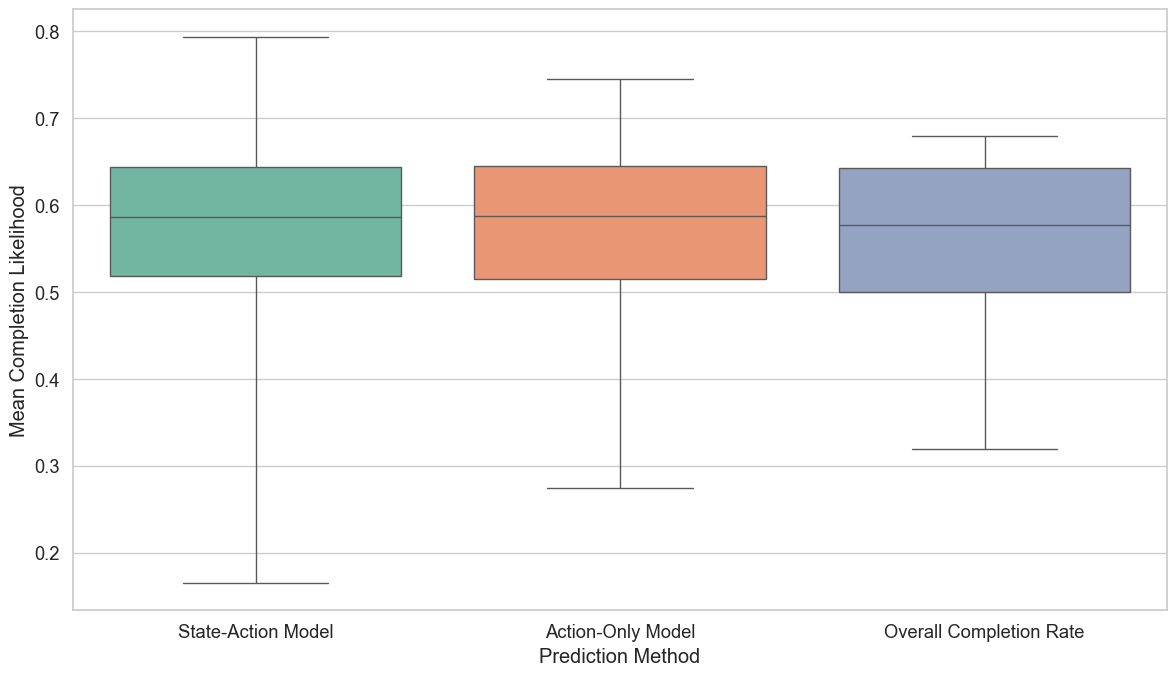


Mean completion likelihoods:
State-Action Model: 0.5774
  95% HDI: [0.2220, 0.8524]
Action-Only Model: 0.5729
  95% HDI: [0.2518, 0.7844]
Overall Completion Rate: 0.5653
  95% HDI: [0.3187, 0.6807]


In [40]:
plot_records = []
model_map = {
    # 'completion_likelihood': 'State-Action Model',
    'completion_likelihood_action_prior': 'State-Action Model',
    'completion_likelihood_action_only': 'Action-Only Model',
    'completion_likelihood_overall': 'Overall Completion Rate'
}

for col, model_name in model_map.items():
    for _, row in combined_results.groupby('user_id').mean().iterrows():
        plot_records.append({
            'Model': model_name,
            'Likelihood': row[col],
            'Completed': 'Completed' if row['completed'] == 1 else 'Not Completed'
            
        })

plot_df = pd.DataFrame(plot_records)


plt.figure(figsize=(12, 7))
sns.set_style("whitegrid")
sns.set_context("notebook", font_scale=1.2)

ax = sns.boxplot(
    data=plot_df, 
    x='Model', 
    y='Likelihood', 
    palette='Set2',
    hue='Model',
    whis=[0, 100]
    # capsize=.05,
    # errorbar=('ci', 95)
)

# sns.stripplot(plot_df, x='Model', y='Likelihood', hue='Model', alpha=0.5)

# plt.title('Completion Likelihood by Prediction Model', fontsize=14)
plt.ylabel('Mean Completion Likelihood')
plt.xlabel('Prediction Method')
plt.savefig(results_folder + "figures/completion_likelihood_comparison.svg", bbox_inches='tight')

plt.tight_layout()
plt.show()

print("\nMean completion likelihoods:")
for col, model_name in model_map.items():
    mean_likelihood = combined_results.groupby('user_id')[col].mean().mean()
    print(f"{model_name}: {mean_likelihood:.4f}")
    hdi = az.hdi(np.array(combined_results[col]), hdi_prob=0.95)   
    print(f"  95% HDI: [{hdi[0]:.4f}, {hdi[1]:.4f}]")

In [ ]:
combined_results['completion_likelihood_diff'] = combined_results['completion_likelihood_action_prior'] - combined_results['completion_likelihood_action_only']
user_diffs = combined_results.groupby('user_id')['completion_likelihood_diff'].mean().values
row = ba.paired_t_test(user_diffs, name="Completion")
pyperclip.copy(ba.to_latex_body(row))
row

Posterior probability improvement > 0: 0.9988
